# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Darren Sluss*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [3]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: darrensluss
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:01<00:00, 272MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['non_fire_images', 'fire_images'] (0 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)


In [4]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

fire: 755 | non-fire: 244
fire share: 0.7557557557557557


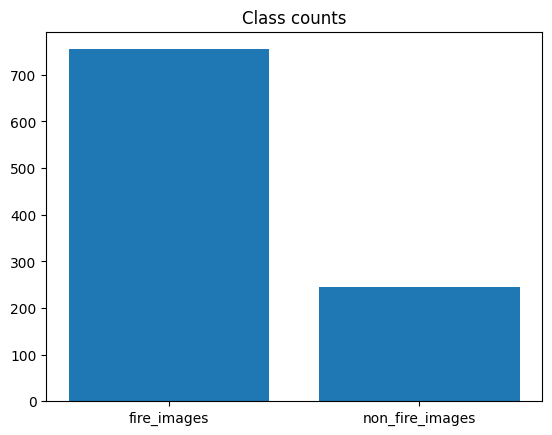

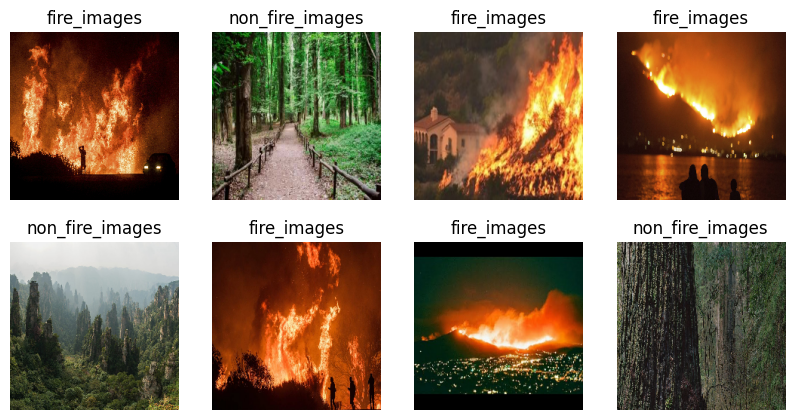

In [5]:
# Your exploration here

fire_n = len(os.listdir(os.path.join(data_dir_fire, "fire_images")))
nonfire_n = len(os.listdir(os.path.join(data_dir_fire, "non_fire_images")))
print("fire:", fire_n, "| non-fire:", nonfire_n)
print("fire share:", fire_n / (fire_n + nonfire_n))

plt.bar(["fire_images", "non_fire_images"], [fire_n, nonfire_n])
plt.title("Class counts")
plt.show()

# peek at a few images
images, labels = next(iter(train_raw_fire))
plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names_fire[labels[i]])
    plt.axis("off")
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

The dataset has 755 fire images and 244 non-fire images. THis means that the set is heavily imbalance. It will be good to look at a confusion matrix here.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [6]:
# Preprocess the data here
def prep(x, y):
    return preprocess_input(x), y

train_fire = train_raw_fire.map(prep).prefetch(tf.data.AUTOTUNE)
val_fire   = val_raw_fire.map(prep).prefetch(tf.data.AUTOTUNE)
test_fire  = test_raw_fire.map(prep).prefetch(tf.data.AUTOTUNE)


In [7]:
# Build your model here

base_fire = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_fire.trainable = False   # freeze the base entirely

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_fire(inputs, training=False)   # training=False, as in lecture
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)   # binary: 1 unit + sigmoid
model_fire = Model(inputs, outputs)
model_fire.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Compile your model here

model_fire.compile(optimizer="adam",
                   loss="binary_crossentropy",
                   metrics=["accuracy"])

## 1D — Train and Evaluate

In [9]:
# Train your model here

history_fire = model_fire.fit(train_fire, validation_data=val_fire, epochs=10)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7586 - loss: 0.4721 - val_accuracy: 0.9065 - val_loss: 0.2662
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9757 - loss: 0.1613 - val_accuracy: 0.9424 - val_loss: 0.1613
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9786 - loss: 0.1021 - val_accuracy: 0.9640 - val_loss: 0.0980
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9814 - loss: 0.0824 - val_accuracy: 0.9640 - val_loss: 0.0838
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9886 - loss: 0.0709 - val_accuracy: 0.9784 - val_loss: 0.0827
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9914 - loss: 0.0625 - val_accuracy: 0.9784 - val_loss: 0.0904
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9914 - loss: 0.0567 - val_accuracy: 0.9640 - val_loss: 0.0994
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9929 - loss: 0.0510 - val_accuracy: 0.9640 - val_loss:

In [11]:
# Report validation and test accuracy here
val_loss, val_acc_fire = model_fire.evaluate(val_fire)
test_loss, test_acc_fire = model_fire.evaluate(test_fire)
print(f"Fire val accuracy:  {val_acc_fire:.4f}")
print(f"Fire test accuracy: {test_acc_fire:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9712 - loss: 0.0826
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9750 - loss: 0.0852
Fire val accuracy:  0.9712
Fire test accuracy: 0.9750


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

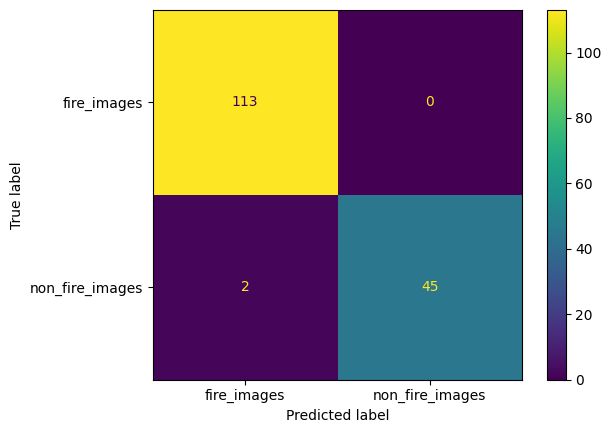

In [12]:
# Build your confusion matrix here

y_true, y_prob = [], []
for x, y in test_fire:
    y_true.extend(y.numpy())
    y_prob.extend(model_fire.predict(x, verbose=0).ravel())

y_true = np.array(y_true)
y_pred = (np.array(y_prob) > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names_fire).plot()
plt.show()

*Your answer:*

In this context, missing a false begative is more costly becuase their can be lives and structures at riak if there is a real fire and it is not properly dealt with. With that in mind, I'd lower the threshold so that the model will favor determining that their is a fire in an image rather than there is not a fire.


---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [13]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['AnnualCrop', 'Highway', 'Industrial', 'PermanentCrop', 'SeaLake', 'Pasture', 'Residential', 'HerbaceousVegetation', 'River', 'Forest']


In [14]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [15]:
# Preprocess the data here

train_sat = train_raw_sat.map(prep).prefetch(tf.data.AUTOTUNE)
val_sat   = val_raw_sat.map(prep).prefetch(tf.data.AUTOTUNE)
test_sat  = test_raw_sat.map(prep).prefetch(tf.data.AUTOTUNE)

In [16]:
# Build your model here

base_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation="softmax")(x)
model_sat = Model(inputs, outputs)

In [17]:
# Compile your model here

model_sat.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

## 2C — Train and Evaluate

In [18]:
# Train your model here
history_sat = model_sat.fit(train_sat, validation_data=val_sat, epochs=5)


Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 878s 1s/step - accuracy: 0.8780 - loss: 0.3811 - val_accuracy: 0.9286 - val_loss: 0.2213
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 966s 2s/step - accuracy: 0.9331 - loss: 0.1959 - val_accuracy: 0.9346 - val_loss: 0.1933
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 916s 2s/step - accuracy: 0.9467 - loss: 0.1596 - val_accuracy: 0.9373 - val_loss: 0.1865
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 911s 2s/step - accuracy: 0.9538 - loss: 0.1390 - val_accuracy: 0.9381 - val_loss: 0.1836
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 869s 1s/step - accuracy: 0.9597 - loss: 0.1219 - val_accuracy: 0.9398 - val_loss: 0.1772


In [19]:
# Report validation and test accuracy here

val_loss, val_acc_sat = model_sat.evaluate(val_sat)
test_loss, test_acc_sat = model_sat.evaluate(test_sat)
print(f"EuroSAT val accuracy:  {val_acc_sat:.4f}")
print(f"EuroSAT test accuracy: {test_acc_sat:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9386 - loss: 0.1811
127/127 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9400 - loss: 0.1786
EuroSAT val accuracy:  0.9386
EuroSAT test accuracy: 0.9400


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

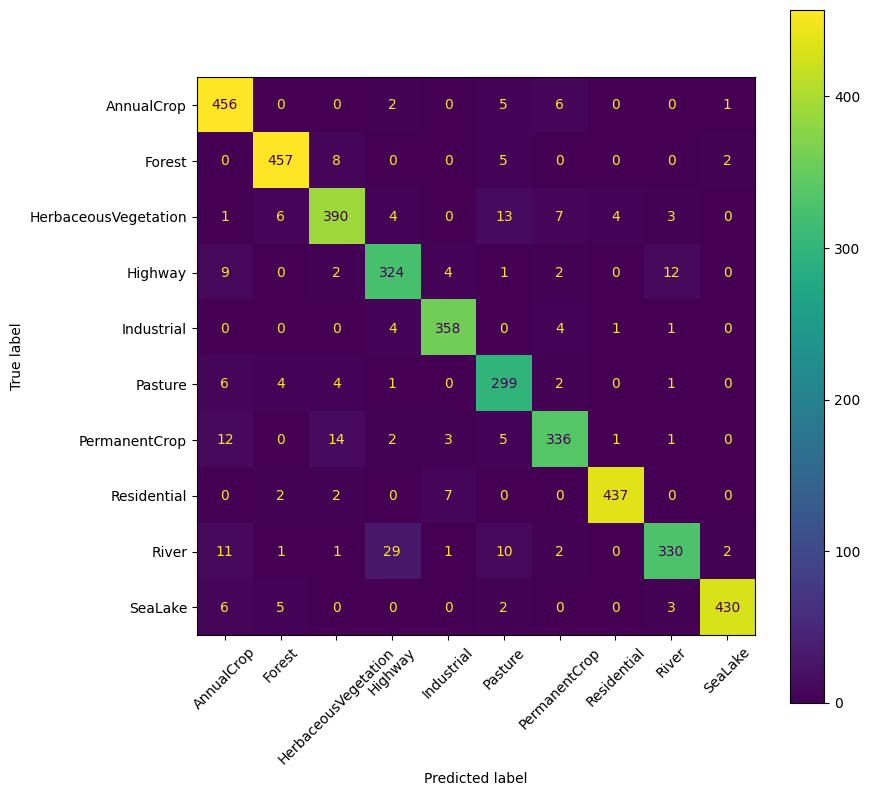

In [20]:
# Build your confusion matrix here

y_true, y_pred = [], []
for x, y in test_sat:
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(model_sat.predict(x, verbose=0), axis=1))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=class_names_sat).plot(ax=ax, xticks_rotation=45)
plt.show()

*Your answer:*




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | | |
| Test Accuracy | | |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.